# When should a policy decide?

A compact tour of **decision schedules**: every period, every few periods,
a delayed start, one opportunity, and irregular opportunities.

A schedule controls **when the policy may order**. The policy decides **how
much**, constraints determine the accepted quantity, and lead time determines
arrival. It does not reschedule demand, callbacks, or the engine's event order.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from stockcast import (
    PeriodicSchedule, OneTimeSchedule, ExplicitSchedule,
    PeriodicReviewPolicy, FixedPeriodicReviewTargets,
    InventoryStateDataFrame, SimulationEngine,
)

schedules = {
    "Every day": PeriodicSchedule(every=1),
    "Every 3 days": PeriodicSchedule(every=3),
    "Every 3 days, start at 2": PeriodicSchedule(every=3, start=2),
    "Once at 0": OneTimeSchedule(period=0),
    "Irregular: 0, 2, 6": ExplicitSchedule(periods=[0, 2, 6]),
}
periods = range(8)

## 1. See the opportunities

Period **0** is the first demand row in this run. On daily data these are days;
on weekly data they are weeks. Decisions precede that period's demand.
A dot means an opportunity, not a promise of a positive order.

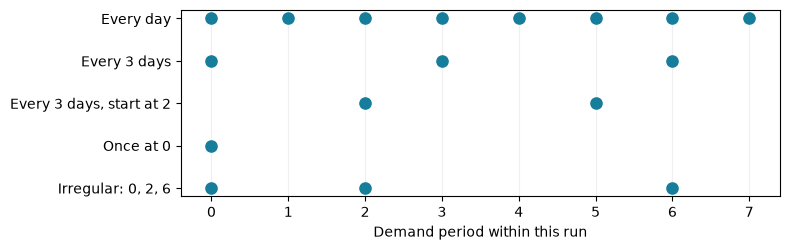

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.6))
for row, (label, schedule) in enumerate(schedules.items()):
    eligible = [t for t in periods if schedule.should_decide(t)]
    ax.scatter(eligible, [row] * len(eligible), s=65, color="#167d9a")
ax.set(yticks=range(len(schedules)), yticklabels=list(schedules),
       xticks=list(periods), xlabel="Demand period within this run", xlim=(-0.4, 7.4))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 2. Run the same rule with different opportunities

Explicit teaching assumptions: one SKU, 8 daily demands of 2 units, opening
stock of 4, no pipeline, zero lead time, and lost sales. At each opportunity,
order up to 8 **only if inventory position is at most 2**. These are fixed
planner thresholds, not estimated quantiles or claimed optimal targets.

Changing the schedule alone is useful for seeing timing. In an operational
model, reconsider the targets too: periodic order-up-to protection is `L+R`,
and irregular opportunities can require different coverage windows.

In [4]:
origin = pd.Timestamp("2026-01-01")
demand = pd.DataFrame({
    "unique_id": ["A"] * 8,
    "date": pd.date_range(origin + pd.Timedelta(days=1), periods=8, freq="D"),
    "y": [2.0] * 8,
    "period": list(periods),
})

def replay(**timing):
    policy = PeriodicReviewPolicy(
        lead_time=0, allow_backorders=False, **timing,
    ).fit(
        pd.DataFrame({"unique_id": ["A"]}),
        target_provider=FixedPeriodicReviewTargets(
            reorder_point=2.0, order_up_to_level=8.0,
        ),
        information_origin=origin, information_frequency="D",
    )
    opening = InventoryStateDataFrame(
        ["A"], max_lead_time=0, allow_backorders=False,
    ).initialize_zero(start_date=origin)
    opening.data["on_hand"] = 4.0
    return SimulationEngine().run(
        policy, demand, opening, n_periods=8,
        period_frequency="D", warmup_periods=0, scoring_periods=8,
        settlement_periods=0, order_during_settlement=False,
        demand_source_name="explicit_schedule_demo", random_seed=None,
    ).to_event_frame()

runs = {name: replay(schedule=schedule) for name, schedule in schedules.items()}
orders = pd.DataFrame({name: events.order_quantity.to_numpy()
                       for name, events in runs.items()}).T
orders.columns = pd.Index(periods, name="Demand period")
orders

Demand period,0,1,2,3,4,5,6,7
Every day,0.0,6.0,0.0,0.0,6.0,0.0,0.0,6.0
Every 3 days,0.0,0.0,0.0,8.0,0.0,0.0,6.0,0.0
"Every 3 days, start at 2",0.0,0.0,8.0,0.0,0.0,6.0,0.0,0.0
Once at 0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Irregular: 0, 2, 6",0.0,0.0,8.0,0.0,0.0,0.0,8.0,0.0


The one-time opportunity at period 0 produces **no order**: opening stock is
above the reorder point, and no later decision is allowed. A one-time schedule
is therefore not automatically a newsvendor policy. Notebook 04d teaches an
explicit seasonal target with `SingleOrderPolicy`.

For example, the every-three-days schedule orders at periods 3 and 6; its
first opportunity at 0 requests zero. Zero-lead orders arrive before current
demand, but cannot recover lost sales from earlier periods.

## 3. No scheduler object required

For ordinary periodic use, just pass `review_period`. The following produces
the same event records as `PeriodicSchedule(every=3)`. Use `review_period=1`
for every demand period. Supply either this shorthand or an explicit schedule;
the engine still needs a rule for when decisions are allowed.

In [5]:
without_schedule_object = replay(review_period=3)
pd.testing.assert_frame_equal(
    without_schedule_object, runs["Every 3 days"],
)
assert runs["Every 3 days"].order_quantity.tolist() == [0, 0, 0, 8, 0, 0, 6, 0]
assert runs["Once at 0"].order_quantity.eq(0).all()
assert runs["Irregular: 0, 2, 6"].decision_flag.tolist() == [
    True, False, True, False, False, False, True, False,
]
print("review_period=3 and PeriodicSchedule(every=3) give identical events.")

review_period=3 and PeriodicSchedule(every=3) give identical events.


**Choose the simplest interface:** `review_period` for regular decisions;
`PeriodicSchedule(..., start=...)` for a delayed first decision;
`OneTimeSchedule` for one opportunity; `ExplicitSchedule` for known irregular
periods. Custom deterministic schedules can subclass `DecisionSchedule`.

Schedules use run-relative demand periods; event and callback period numbers
retain the opening-state offset. Rolling fitted-policy updates (`policy_schedule`)
are separate from decision opportunities. See the
[decision-schedule guide](../../docs/concepts/decision-schedules.md) for details,
and [Notebook 03](03_component_loop.ipynb) for a caller-owned loop.